# Source pretraining → target fine-tuning

First train the top k Graphormer layers + head on in vitro (source) labels, then fine-tune on in vivo (target).

**Stage 1 — Pretraining (once per property and seed)**
- use the whole source, but **exclude molecules that overlap with the target (any fold)** → test molecules are never seen during pretraining
- early stopping on a scaffold 90/10 split within the source (source val R²)

**Stage 2 — Fine-tuning (same conditions as 09)**
- load the pretrained top k layers and re-initialise the head (changeable with `HEAD_INIT`)
- split, learning rate, early stopping and seed (`seed*100+fold`) match 09 → **the only difference is the initialisation (pretrained or not)**
- comparison: per-fold paired t-test against the frozen baseline (08) / target-only fine-tune (09)

**Extra diagnostic — Zero-shot**: Spearman ρ of the pretrained model applied directly to the target test set (how well in vitro predictions rank in vivo values)

To save memory, the lower-layer Graphormer cache is stored **on disk (float16 memmap)** (`results/pretrain_ft/cache/`, reused once built).

**Kernel: `esu_gpu (CUDA)`**

## 0. Settings

In [21]:
import copy
import os
import sys
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from rdkit import Chem, RDLogger
from scipy.stats import spearmanr, ttest_rel
from sklearn.metrics import r2_score

RDLogger.DisableLog('rdApp.*')
ROOT = r'..'
sys.path.insert(0, ROOT)
sys.path.insert(0, os.path.join(ROOT, '01_model'))
from src.graphormer_encoder import load_encoder, embed
from src.graphormer_preprocess import collate, preprocess_smiles
from train_utils import split_train_val, fit_early_stopping

DATA_DIR = os.path.join(ROOT, 'data', 'cv_datasets')
OUT_DIR = os.path.join(ROOT, 'results', 'pretrain_ft')
CACHE_DIR = os.path.join(OUT_DIR, 'cache')
os.makedirs(CACHE_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PROPERTIES = ['clearance', 'half_life', 'fu']
N_FOLDS = 5
SEEDS = [0, 1, 2]
K = 4                       # number of top layers to unfreeze (compare with k=4 in 09)
CACHE_LAYER = 8
MAX_NODES = 128

# Stage 1: pretraining
PRE_LR_BACKBONE = 5e-5
PRE_LR_HEAD = 1e-3
PRE_BATCH = 64
PRE_MAX_EPOCHS = 30
PRE_PATIENCE = 5
PRE_VAL_FRAC = 0.1

# Stage 2: fine-tuning (same as 09)
LR_BACKBONE = 2e-5
LR_HEAD = 1e-3
WEIGHT_DECAY = 1e-4
BATCH = 32
HEAD_INIT = 'new'           # 'new' = re-initialise the head / 'pretrained' = keep the pretrained head

print('Device:', DEVICE, torch.cuda.get_device_name(0) if torch.cuda.is_available() else '')
assert DEVICE.type == 'cuda', 'Please switch the kernel to esu_gpu (CUDA)'

Device: cuda NVIDIA GeForce RTX 3060


## 1. Data: source (overlap excluded) + target

In [22]:
def inchikey14(s):
    """First InChIKey block (connectivity) — unaffected by protonation or ion notation (same format as the target's 'ik' column)"""
    m = Chem.MolFromSmiles(str(s))
    return Chem.MolToInchiKey(m)[:14] if m is not None else None

source, target_smiles = {}, {}
for prop in PROPERTIES:
    tgt = pd.concat([pd.read_csv(os.path.join(DATA_DIR, f'fold_{fold}', f'{prop}_target_{split}.csv'))
                     for fold in range(N_FOLDS) for split in ['train', 'test']])
    target_smiles[prop] = sorted(set(tgt['smiles'].astype(str)))
    tgt_ik = set(tgt['ik'].dropna())

    src = pd.read_csv(os.path.join(DATA_DIR, 'fold_0', f'{prop}_source.csv'), low_memory=False)[['smiles', 'value']]
    src = src.dropna()
    overlap = src['smiles'].map(inchikey14).isin(tgt_ik)
    source[prop] = src[~overlap].reset_index(drop=True)
    print(f'{prop:<10} source {len(src):>6} → {len(source[prop]):>6} (excluded for target overlap: {overlap.sum()} rows, '
          f'{src.loc[overlap, "smiles"].nunique()} molecules) | target {len(target_smiles[prop])} molecules')

clearance  source  14387 →  14387 (excluded for target overlap: 0 rows, 0 molecules) | target 1027 molecules
half_life  source   9204 →   9204 (excluded for target overlap: 0 rows, 0 molecules) | target 1164 molecules
fu         source   3783 →   3783 (excluded for target overlap: 0 rows, 0 molecules) | target 353 molecules


## 2. Lower-layer Graphormer cache (disk memmap, float16)

Layer 0-7 outputs (hidden) and attention bias are appended per molecule into one file. Built per property; loaded if it already exists.

In [23]:
def _prefix(enc, batch):
    x_in = batch['input_nodes']
    pm = x_in[:, :, 0].eq(0)
    pm = torch.cat([torch.zeros(x_in.size(0), 1, dtype=pm.dtype, device=x_in.device), pm], 1)
    ab = enc.graph_attn_bias(x_in, batch['attn_bias'], batch['spatial_pos'], batch['input_edges'], batch['attn_edge_type'])
    x = enc.graph_node_feature(x_in, batch['in_degree'], batch['out_degree'])
    if enc.emb_layer_norm is not None:
        x = enc.emb_layer_norm(x)
    x = x.transpose(0, 1)
    for layer in enc.layers[:CACHE_LAYER]:
        x, _ = layer(x, self_attn_padding_mask=pm, self_attn_bias=ab)
    return x, ab, (~pm).sum(1)


class DiskCache:
    """smiles → (hidden[T,C], bias[H,T,T]) — read from the float16 memmap and returned as float32 tensors"""
    def __init__(self, prefix, C=768, H=32):
        idx = pd.read_csv(prefix + '_index.csv')
        self.pos = {s: (int(h), int(b), int(t)) for s, h, b, t in idx[['smiles', 'h_off', 'b_off', 'T']].itertuples(index=False)}
        self.hid = np.memmap(prefix + '_hidden.f16', dtype=np.float16, mode='r')
        self.bias = np.memmap(prefix + '_bias.f16', dtype=np.float16, mode='r')
        self.C, self.H = C, H

    def __contains__(self, s):
        return s in self.pos

    def __len__(self):
        return len(self.pos)

    def __getitem__(self, s):
        h, b, t = self.pos[s]
        hid = torch.from_numpy(self.hid[h:h + t * self.C].astype(np.float32).reshape(t, self.C))
        bias = torch.from_numpy(self.bias[b:b + self.H * t * t].astype(np.float32).reshape(self.H, t, t))
        return hid, bias


@torch.no_grad()
def build_disk_cache(enc, cfg, smiles_list, prefix, chunk=512, batch_size=32):
    """Preprocess → compute → append to file chunk by chunk (only one chunk sits in RAM)"""
    C, H = enc.embedding_dim, cfg.num_attention_heads
    rows, h_off, b_off = [], 0, 0
    with open(prefix + '_hidden.f16', 'wb') as fh, open(prefix + '_bias.f16', 'wb') as fb:
        for c0 in range(0, len(smiles_list), chunk):
            items, keys = [], []
            for s in smiles_list[c0:c0 + chunk]:
                it = preprocess_smiles(s)
                if it is not None and it['num_nodes'] <= MAX_NODES:
                    items.append(it)
                    keys.append(s)
            for i in range(0, len(items), batch_size):
                b = {k: v.to(DEVICE) for k, v in collate(items[i:i + batch_size], spatial_pos_max=cfg.spatial_pos_max).items()}
                x, ab, n = _prefix(enc, b)
                x, ab = x.half().cpu().numpy(), ab.half().cpu().numpy()
                for j, s in enumerate(keys[i:i + batch_size]):
                    t = int(n[j])
                    fh.write(np.ascontiguousarray(x[:t, j]).tobytes())
                    fb.write(np.ascontiguousarray(ab[j, :, :t, :t]).tobytes())
                    rows.append((s, h_off, b_off, t))
                    h_off += t * C
                    b_off += H * t * t
            print(f'  {min(c0 + chunk, len(smiles_list))}/{len(smiles_list)}', end='\r')
    pd.DataFrame(rows, columns=['smiles', 'h_off', 'b_off', 'T']).to_csv(prefix + '_index.csv', index=False)


def pad_batch(entries):
    T = max(h.shape[0] for h, _ in entries)
    B, C, H = len(entries), entries[0][0].shape[1], entries[0][1].shape[0]
    x, ab, pm = torch.zeros(T, B, C), torch.zeros(B, H, T, T), torch.ones(B, T, dtype=torch.bool)
    for j, (h, b) in enumerate(entries):
        t = h.shape[0]
        x[:t, j], ab[j, :, :t, :t], pm[j, :t] = h, b, False
    return x.to(DEVICE), ab.to(DEVICE), pm.to(DEVICE)

In [24]:
enc, cfg = load_encoder(DEVICE)
enc.eval()

caches = {}
for prop in PROPERTIES:
    prefix = os.path.join(CACHE_DIR, prop)
    if not os.path.exists(prefix + '_index.csv'):
        smiles = sorted(set(source[prop]['smiles']) | set(target_smiles[prop]))
        t0 = time.time()
        build_disk_cache(enc, cfg, smiles, prefix)
        print(f'{prop}: cache built ({time.time() - t0:.0f}s)          ')
    caches[prop] = DiskCache(prefix)
    size_gb = (os.path.getsize(prefix + '_hidden.f16') + os.path.getsize(prefix + '_bias.f16')) / 1e9
    print(f'{prop:<10} cached molecules: {len(caches[prop])} ({size_gb:.2f} GB on disk)')

[graphormer] loaded 202 tensors | missing=0 unexpected=0
clearance  cached molecules: 14592 (1.62 GB on disk)
half_life  cached molecules: 9639 (1.21 GB on disk)
fu         cached molecules: 3946 (0.47 GB on disk)


In [25]:
# Cache check: float16 cache → remaining layers vs the original full forward (error below ~1e-2 is normal for float16)
with torch.no_grad():
    cache = caches['fu']
    sample = target_smiles['fu'][:16]
    ref = embed(enc, collate([preprocess_smiles(s) for s in sample], spatial_pos_max=cfg.spatial_pos_max), DEVICE)
    x, ab, pm = pad_batch([cache[s] for s in sample])
    for layer in enc.layers[CACHE_LAYER:]:
        x, _ = layer(x, self_attn_padding_mask=pm, self_attn_bias=ab)
    out = x[0].cpu()
    print(f'max |Δ| = {float((out - ref).abs().max()):.2e} | cosine min = '
          f'{float(torch.nn.functional.cosine_similarity(out, ref).min()):.6f}')

max |Δ| = 1.82e-03 | cosine min = 1.000000


## 3. Model (same architecture as 09)

In [26]:
class FTRegressor(nn.Module):
    def __init__(self, enc, k, d_hidden=256, dropout=0.2):
        super().__init__()
        n_layers = len(enc.layers)
        self.mid = nn.ModuleList(enc.layers[CACHE_LAYER:n_layers - k])
        self.top = nn.ModuleList([copy.deepcopy(l) for l in enc.layers[n_layers - k:]])
        for p in self.mid.parameters():
            p.requires_grad_(False)
        for p in self.top.parameters():
            p.requires_grad_(True)
        d = enc.embedding_dim
        self.head = nn.Sequential(
            nn.Linear(d, d_hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_hidden, d_hidden // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_hidden // 2, 1),
        )

    def train(self, mode=True):
        super().train(mode)
        self.mid.eval()
        return self

    def forward(self, x, ab, pm):
        with torch.no_grad():
            for layer in self.mid:
                x, _ = layer(x, self_attn_padding_mask=pm, self_attn_bias=ab)
        for layer in self.top:
            x, _ = layer(x, self_attn_padding_mask=pm, self_attn_bias=ab)
        return self.head(x[0]).squeeze(-1)

    def param_groups(self, lr_backbone, lr_head):
        return [{'params': self.head.parameters(), 'lr': lr_head, 'weight_decay': WEIGHT_DECAY},
                {'params': self.top.parameters(), 'lr': lr_backbone, 'weight_decay': WEIGHT_DECAY}]


@torch.no_grad()
def predict(model, smiles, cache):
    model.eval()
    return np.concatenate([model(*pad_batch([cache[s] for s in smiles[i:i + 128]])).cpu().numpy()
                           for i in range(0, len(smiles), 128)])


def metrics(y, p):
    return {'r2': r2_score(y, p), 'rho': spearmanr(y, p)[0], 'rmse': float(np.sqrt(np.mean((y - p) ** 2))), 'mae': float(np.mean(np.abs(y - p)))}


def train_epoch(model, smiles, y, opt, crit, cache, batch):
    model.train()
    perm = np.random.permutation(len(smiles))
    for i in range(0, len(smiles), batch):
        idx = perm[i:i + batch]
        opt.zero_grad()
        loss = crit(model(*pad_batch([cache[smiles[j]] for j in idx])), torch.tensor(y[idx], device=DEVICE))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()

## 4. Stage 1 — Source pretraining

Once per property × seed. Weights are saved to `results/pretrain_ft/pretrained_{prop}_k{K}_s{seed}.pt` and skipped if present.

In [27]:
pre_log_path = os.path.join(OUT_DIR, 'pretrain_log.csv')
pre_log = pd.read_csv(pre_log_path).to_dict('records') if os.path.exists(pre_log_path) else []

for prop in PROPERTIES:
    cache = caches[prop]
    src = source[prop][source[prop]['smiles'].isin(set(cache.pos))]
    s_smiles, s_y = src['smiles'].tolist(), src['value'].to_numpy('float32')
    tr_i, _, va_i, _ = split_train_val(np.arange(len(s_smiles)), s_y, 99, smiles=s_smiles, val_frac=PRE_VAL_FRAC)
    fit_s, fit_y = [s_smiles[i] for i in tr_i], s_y[tr_i]
    val_s, val_y = [s_smiles[i] for i in va_i], s_y[va_i]

    for seed in SEEDS:
        path = os.path.join(OUT_DIR, f'pretrained_{prop}_k{K}_s{seed}.pt')
        if os.path.exists(path):
            print(f'{prop:<10} seed={seed}: already exists → skipped')
            continue
        torch.manual_seed(10000 + seed)
        np.random.seed(10000 + seed)
        model = FTRegressor(enc, K).to(DEVICE)
        opt = torch.optim.AdamW(model.param_groups(PRE_LR_BACKBONE, PRE_LR_HEAD))
        crit = nn.HuberLoss(delta=1.0)
        t0 = time.time()
        best_epoch, best_val = fit_early_stopping(
            model, lambda: train_epoch(model, fit_s, fit_y, opt, crit, cache, PRE_BATCH),
            lambda m, X, Y: metrics(Y, predict(m, X, cache)), val_s, val_y,
            max_epochs=PRE_MAX_EPOCHS, patience=PRE_PATIENCE)
        torch.save({'top': model.top.state_dict(), 'head': model.head.state_dict()}, path)
        pre_log.append({'property': prop, 'seed': seed, 'n_train': len(fit_s), 'n_val': len(val_s),
                        'best_epoch': best_epoch, 'source_val_r2': best_val, 'sec': time.time() - t0})
        pd.DataFrame(pre_log).to_csv(pre_log_path, index=False)
        print(f'{prop:<10} seed={seed}: source val r2={best_val:.4f} | best_epoch={best_epoch} | {time.time() - t0:.0f}s')
        del model, opt

pd.DataFrame(pre_log)

clearance  seed=0: already exists → skipped
clearance  seed=1: already exists → skipped
clearance  seed=2: already exists → skipped
half_life  seed=0: already exists → skipped
half_life  seed=1: already exists → skipped
half_life  seed=2: already exists → skipped
fu         seed=0: already exists → skipped
fu         seed=1: already exists → skipped
fu         seed=2: already exists → skipped


,property,seed,n_train,n_val,best_epoch,source_val_r2,sec
0,clearance,0,12946,1440,9,0.314106,365.764827
1,clearance,1,12946,1440,19,0.329029,608.777605
2,clearance,2,12946,1440,17,0.341100,553.761578
3,half_life,0,8272,930,12,0.378827,314.025051
4,half_life,1,8272,930,17,0.401243,380.522552
5,half_life,2,8272,930,14,0.428628,325.129376
6,fu,0,3380,398,19,0.534338,178.009802
7,fu,1,3380,398,19,0.582546,191.728865
8,fu,2,3380,398,26,0.550868,214.774118


## 5. Stage 2 — Target fine-tuning (+ zero-shot diagnostic)

3 properties × 3 seeds × 5 folds = 45 runs. If interrupted, re-running skips finished combinations.

In [28]:
def load_split(prop, fold, split, cache):
    df = pd.read_csv(os.path.join(DATA_DIR, f'fold_{fold}', f'{prop}_target_{split}.csv'))
    keep = [(s, y) for s, y in zip(df['smiles'].astype(str), df['value']) if s in cache]
    return [s for s, _ in keep], np.array([y for _, y in keep], dtype='float32')


def run_one(prop, fold, seed):
    cache = caches[prop]
    tr_s, tr_y = load_split(prop, fold, 'train', cache)
    te_s, te_y = load_split(prop, fold, 'test', cache)
    tr_i, _, va_i, _ = split_train_val(np.arange(len(tr_s)), tr_y, fold, smiles=tr_s)
    fit_s, fit_y = [tr_s[i] for i in tr_i], tr_y[tr_i]
    val_s, val_y = [tr_s[i] for i in va_i], tr_y[va_i]

    torch.manual_seed(seed * 100 + fold)   # same seed formula as 09
    np.random.seed(seed * 100 + fold)
    model = FTRegressor(enc, K).to(DEVICE)
    state = torch.load(os.path.join(OUT_DIR, f'pretrained_{prop}_k{K}_s{seed}.pt'), map_location=DEVICE)
    model.top.load_state_dict(state['top'])
    if HEAD_INIT == 'pretrained':
        model.head.load_state_dict(state['head'])

    # zero-shot: rank-predict the target test set with the pretrained model (pretrained head)
    zs = FTRegressor(enc, K).to(DEVICE)
    zs.top.load_state_dict(state['top'])
    zs.head.load_state_dict(state['head'])
    zs_pred = predict(zs, te_s, cache)
    zero_shot_rho = spearmanr(te_y, zs_pred)[0]
    del zs

    opt = torch.optim.AdamW(model.param_groups(LR_BACKBONE, LR_HEAD))
    crit = nn.HuberLoss(delta=1.0)
    t = time.time()
    best_epoch, best_val = fit_early_stopping(
        model, lambda: train_epoch(model, fit_s, fit_y, opt, crit, cache, BATCH),
        lambda m, X, Y: metrics(Y, predict(m, X, cache)), val_s, val_y)
    te_pred = predict(model, te_s, cache)
    PRED_ROWS.append(pd.DataFrame({'property': prop, 'seed': seed, 'fold': fold, 'smiles': te_s, 'y_true': te_y,
                                   'y_pred': te_pred, 'y_pred_zero_shot': zs_pred}))  # zero-shot is on the source scale (for ranking)
    return {'property': prop, 'seed': seed, 'fold': fold, **metrics(te_y, te_pred),
            'val_r2': best_val, 'best_epoch': best_epoch, 'zero_shot_rho': zero_shot_rho, 'sec': time.time() - t}


runs_path = os.path.join(OUT_DIR, 'runs.csv')
rows = pd.read_csv(runs_path).to_dict('records') if os.path.exists(runs_path) else []
done = {(r['property'], r['seed'], r['fold']) for r in rows}
KEY_COLS = ['property', 'seed', 'fold']
# Per-compound test predictions (y_true and y_pred in per-fold z-score units). Combinations already in runs.csv are skipped,
# so to collect predictions again, move the existing runs.csv to another name (e.g. runs_v1.csv) before running.
preds_path = os.path.join(OUT_DIR, 'predictions.csv')
PRED_ROWS = [pd.read_csv(preds_path)] if os.path.exists(preds_path) else []
pred_done = set(map(tuple, PRED_ROWS[0][KEY_COLS].drop_duplicates().to_numpy())) if PRED_ROWS else set()
if done - pred_done:
    print(f'Warning: {len(done - pred_done)} combinations are only in runs.csv without predictions → move runs.csv and re-run to save predictions as well')
print(f'Already done: {len(done)} runs')

t0 = time.time()
for prop in PROPERTIES:
    for seed in SEEDS:
        new = [run_one(prop, fold, seed) for fold in range(N_FOLDS) if (prop, seed, fold) not in done]
        if new:
            rows += new
            pd.DataFrame(rows).to_csv(runs_path, index=False)
            pd.concat(PRED_ROWS, ignore_index=True).to_csv(preds_path, index=False)
            d = pd.DataFrame(new)
            print(f'{prop:<10} seed={seed} | test r2={d["r2"].mean():.4f} rho={d["rho"].mean():.4f} | '
                  f'zero-shot rho={d["zero_shot_rho"].mean():.4f} | best_epoch={d["best_epoch"].mean():.1f} | {time.time() - t0:.0f}s')
runs = pd.DataFrame(rows)
print('Done:', len(runs), 'runs')

Already done: 0 runs


~\AppData\Local\Temp\ipykernel_15504\692020003.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(os.path.join(OUT_DIR, f'pretrained_{prop}_k{K}_s{seed}

clearance  seed=0 | test r2=0.1059 rho=0.3861 | zero-shot rho=0.1462 | best_epoch=33.4 | 390s


~\AppData\Local\Temp\ipykernel_15504\692020003.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(os.path.join(OUT_DIR, f'pretrained_{prop}_k{K}_s{seed}

clearance  seed=1 | test r2=0.1459 rho=0.4070 | zero-shot rho=0.1197 | best_epoch=24.2 | 701s


...

fu         seed=0 | test r2=0.3482 rho=0.6569 | zero-shot rho=0.5697 | best_epoch=22.0 | 2016s


~\AppData\Local\Temp\ipykernel_15504\692020003.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(os.path.join(OUT_DIR, f'pretrained_{prop}_k{K}_s{seed}

fu         seed=1 | test r2=0.3471 rho=0.6421 | zero-shot rho=0.5958 | best_epoch=3.8 | 2067s


~\AppData\Local\Temp\ipykernel_15504\692020003.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(os.path.join(OUT_DIR, f'pretrained_{prop}_k{K}_s{seed}

fu         seed=2 | test r2=0.3397 rho=0.6629 | zero-shot rho=0.5694 | best_epoch=13.0 | 2143s
Done: 45  runs


## 6. Comparison: frozen / target-only fine-tune (09) / fine-tune after pretraining

All with the same seeds 0-2 and the same folds. Paired t-test on per-fold seed means (n=5).

In [29]:
runs = pd.read_csv(os.path.join(OUT_DIR, 'runs.csv'))
frozen = pd.read_csv(os.path.join(ROOT, 'results', 'significance', 'runs.csv'))
frozen = frozen[(frozen['method'] == 'Baseline') & (frozen['seed'].isin(SEEDS))]
ft09 = pd.read_csv(os.path.join(ROOT, 'results', 'finetune', 'runs.csv'))
ft09 = ft09[(ft09['k'] == K) & (ft09['seed'].isin(SEEDS))]

models = {'frozen': frozen, f'target-only FT (k={K})': ft09, f'pretrain → FT (k={K})': runs}
out = []
for prop in PROPERTIES:
    fold_r2 = {name: d[d['property'] == prop].groupby('fold')['r2'].mean() for name, d in models.items()}
    for name, d in models.items():
        d = d[d['property'] == prop]
        row = {'property': prop, 'model': name, 'r2_mean': d['r2'].mean(), 'rho_mean': d['rho'].mean(),
               'rmse_mean': d['rmse'].mean(), 'best_epoch_mean': d['best_epoch'].mean()}
        if name.startswith('pretrain'):
            for ref in ['frozen', f'target-only FT (k={K})']:
                tag = 'frozen' if ref == 'frozen' else 'ft09'
                row[f'delta_r2_vs_{tag}'] = (fold_r2[name] - fold_r2[ref]).mean()
                row[f'p_vs_{tag}'] = ttest_rel(fold_r2[name], fold_r2[ref]).pvalue
            row['zero_shot_rho'] = d['zero_shot_rho'].mean()
        out.append(row)
summary = pd.DataFrame(out)
summary.to_csv(os.path.join(OUT_DIR, 'summary.csv'), index=False)
summary.style.format({c: '{:.4f}' for c in ['r2_mean', 'rho_mean', 'rmse_mean', 'zero_shot_rho']}
                     | {'best_epoch_mean': '{:.1f}', 'delta_r2_vs_frozen': '{:+.4f}', 'delta_r2_vs_ft09': '{:+.4f}',
                        'p_vs_frozen': '{:.3f}', 'p_vs_ft09': '{:.3f}'}, na_rep='–')

,property,model,r2_mean,rho_mean,rmse_mean,best_epoch_mean,delta_r2_vs_frozen,p_vs_frozen,delta_r2_vs_ft09,p_vs_ft09,zero_shot_rho
0,clearance,frozen,0.0999,0.3714,0.9465,14.8,–,–,–,–,–
1,clearance,target-only FT (k=4),0.0898,0.3673,0.9500,13.9,–,–,–,–,–
2,clearance,pretrain → FT (k=4),0.1186,0.3926,0.9358,26.7,+0.0186,0.298,+0.0288,0.237,0.1291
3,half_life,frozen,0.1067,0.4052,0.9376,8.9,–,–,–,–,–
4,half_life,target-only FT (k=4),0.1131,0.4285,0.9327,8.4,–,–,–,–,–
5,half_life,pretrain → FT (k=4),0.1470,0.4410,0.9156,18.9,+0.0402,0.192,+0.0338,0.111,0.0364
6,fu,frozen,0.2485,0.5856,0.8448,9.5,–,–,–,–,–
7,fu,target-only FT (k=4),0.2788,0.6222,0.8291,8.1,–,–,–,–,–
8,fu,pretrain → FT (k=4),0.3450,0.6539,0.7872,12.9,+0.0965,0.030,+0.0662,0.041,0.5783


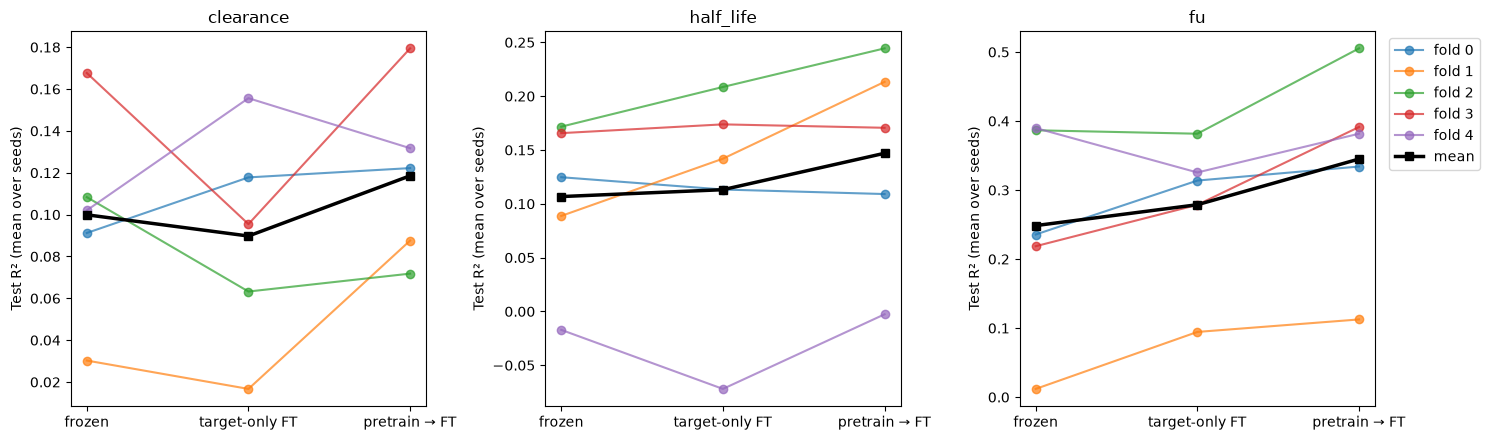

In [30]:
order = list(models)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, prop in zip(axes, PROPERTIES):
    piv = pd.DataFrame({name: d[d['property'] == prop].groupby('fold')['r2'].mean() for name, d in models.items()})[order]
    for fold, row in piv.iterrows():
        ax.plot(range(len(order)), row.values, marker='o', alpha=0.7, label=f'fold {fold}')
    ax.plot(range(len(order)), piv.mean().values, color='black', lw=2.5, marker='s', label='mean')
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(['frozen', 'target-only FT', 'pretrain → FT'])
    ax.set_title(prop)
    ax.set_ylabel('Test R² (mean over seeds)')
axes[-1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()